In [1]:
import os
import random
import time
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms, models

# Configurar semente aleatória para reprodutibilidade
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Configurar dispositivo (GPU se disponível)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando o dispositivo: {device}")
if torch.cuda.is_available():
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")

Usando o dispositivo: cuda
GPU detectada: NVIDIA GeForce RTX 5060 Ti


In [2]:
import kagglehub

# Retorna o caminho dos arquivos do dataset baixado
DATASET_PATH = kagglehub.dataset_download("dariobaumberger/combined-kaggle-mushrooms-dataset")
print("Caminho das imagens do dataset:", DATASET_PATH)

TARGET_CLASSES = [
    'Xanthoria parietina',
    'Fomes fomentarius',
    'Fomitopsis pinicola',
    'Amanita muscaria',
    'Laetiporus sulphureus'
]

IMAGES_DIR = os.path.join(DATASET_PATH, 'images')

# Mapear classes para índices e vice-versa
class_to_idx = {cls: idx for idx, cls in enumerate(TARGET_CLASSES)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}
print("Mapeamento de classes:", class_to_idx)

Caminho das imagens do dataset: C:\Users\tutul\.cache\kagglehub\datasets\dariobaumberger\combined-kaggle-mushrooms-dataset\versions\3
Mapeamento de classes: {'Xanthoria parietina': 0, 'Fomes fomentarius': 1, 'Fomitopsis pinicola': 2, 'Amanita muscaria': 3, 'Laetiporus sulphureus': 4}


In [3]:
image_paths = []
labels = []

for cls in TARGET_CLASSES:
    cls_dir = os.path.join(IMAGES_DIR, cls)
    cls_files = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp'))]
    
    # Amostrar exatamente 1000 imagens aleatórias por classe
    sampled_files = random.sample(cls_files, min(1000, len(cls_files)))
    
    image_paths.extend(sampled_files)
    labels.extend([class_to_idx[cls]] * len(sampled_files))

# Criar um dataframe facilitando a visualização e manipulação
df = pd.DataFrame({
    'image_path': image_paths,
    'label': labels,
    'class_name': [idx_to_class[l] for l in labels]
})

print(f"Total de imagens carregadas na amostra: {len(df)}")
print("Quantidade de imagens por espécie:")
print(df['class_name'].value_counts())

Total de imagens carregadas na amostra: 5000
Quantidade de imagens por espécie:
class_name
Xanthoria parietina      1000
Fomes fomentarius        1000
Fomitopsis pinicola      1000
Amanita muscaria         1000
Laetiporus sulphureus    1000
Name: count, dtype: int64


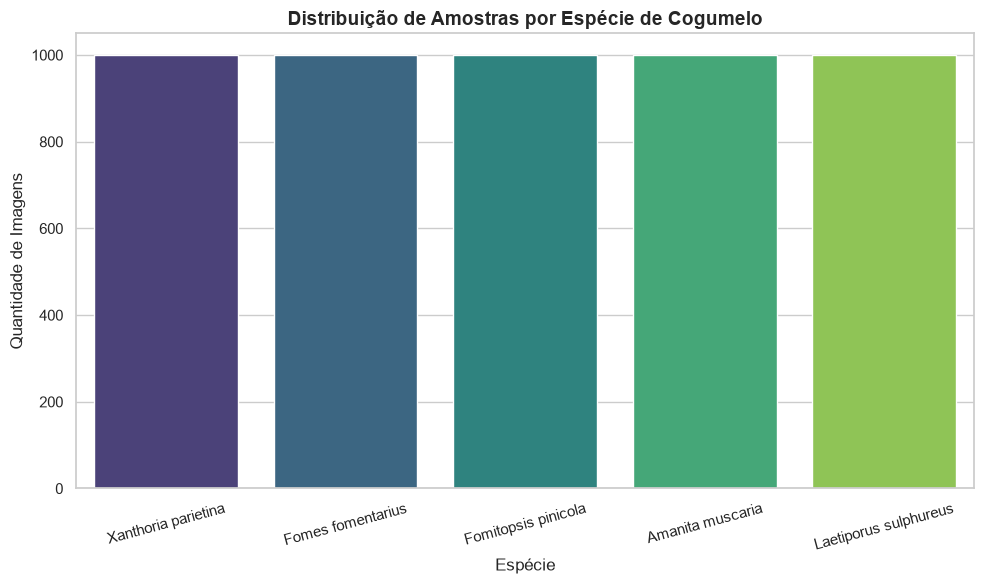

In [4]:
# Criar gráfico de contagem das classes amostradas
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.countplot(data=df, x='class_name', order=TARGET_CLASSES, hue='class_name', palette='viridis', legend=False)
plt.title('Distribuição de Amostras por Espécie de Cogumelo', fontsize=14, fontweight='bold')
plt.xlabel('Espécie', fontsize=12)
plt.ylabel('Quantidade de Imagens', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()

# Criar pasta de gráficos caso não exista e salvar o gráfico
os.makedirs('graficos', exist_ok=True)
plt.savefig('graficos/distribuicao_classes.png', dpi=300)
plt.show()

findfont: Failed to find font weight semibold, now using 700.


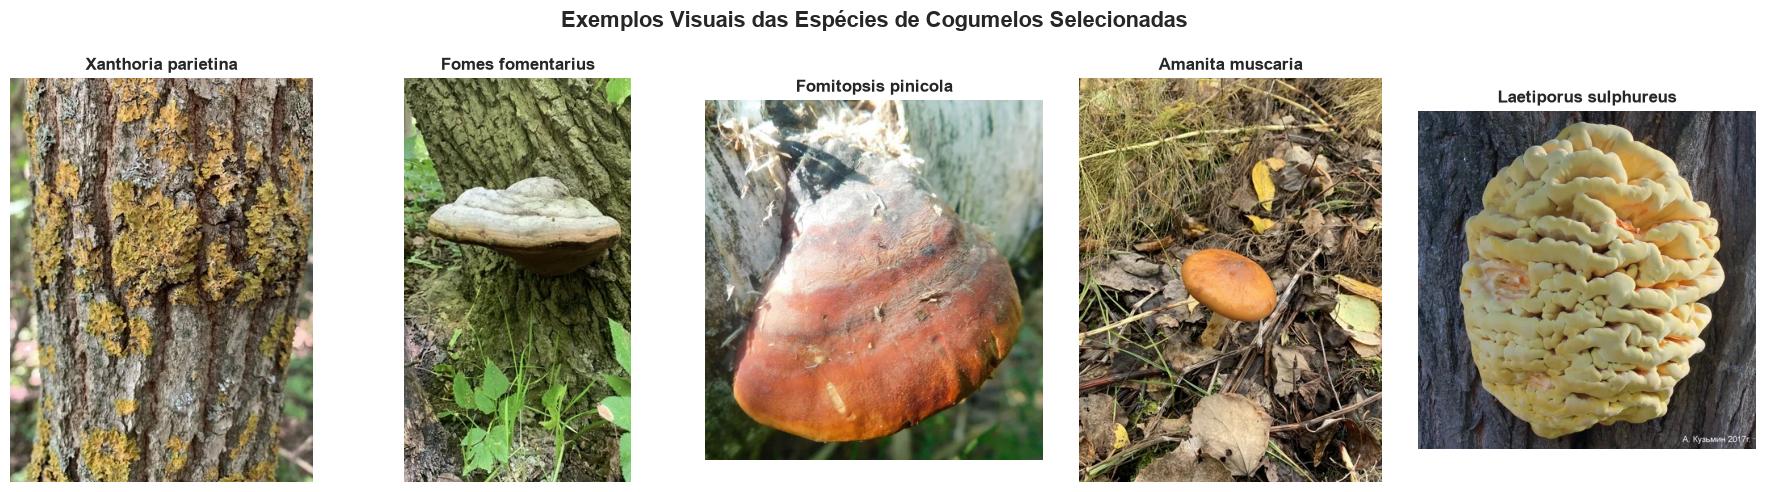

In [5]:
# Exibir um grid contendo exemplos das imagens selecionadas
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('Exemplos Visuais das Espécies de Cogumelos Selecionadas', fontsize=16, fontweight='bold')

for idx, cls in enumerate(TARGET_CLASSES):
    # Pegar uma imagem correspondente à espécie atual
    sample_path = df[df['class_name'] == cls]['image_path'].iloc[0]
    img = Image.open(sample_path)
    
    axes[idx].imshow(img)
    axes[idx].set_title(cls, fontsize=12, fontweight='semibold')
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('graficos/exemplos_visuais.png', dpi=300)
plt.show()

In [6]:
# Divisão de conjuntos estratificada
train_df, temp_df = train_test_split(
    df, 
    test_size=0.30, 
    random_state=42, 
    stratify=df['label']
)

val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.50, 
    random_state=42, 
    stratify=temp_df['label']
)

print(f"Treino: {len(train_df)} imagens ({len(train_df)/len(df)*100:.1f}%)")
print(f"Validação: {len(val_df)} imagens ({len(val_df)/len(df)*100:.1f}%)")
print(f"Teste: {len(test_df)} imagens ({len(test_df)/len(df)*100:.1f}%)")

Treino: 3500 imagens (70.0%)
Validação: 750 imagens (15.0%)
Teste: 750 imagens (15.0%)


In [7]:
class MushroomDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        
    def __len__(self):
        return len(self.dataframe)
        
    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, 'image_path']
        label = self.dataframe.loc[idx, 'label']
        
        # Abrir e converter a imagem para 3 canais de cor
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [8]:
IMG_SIZE = 128

# Normalização padrão utilizada no ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Instanciar os Datasets e Dataloaders do PyTorch
train_dataset = MushroomDataset(train_df, transform=train_transforms)
val_dataset = MushroomDataset(val_df, transform=val_test_transforms)
test_dataset = MushroomDataset(test_df, transform=val_test_transforms)

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print("DataLoaders instanciados e configurados com sucesso!")

DataLoaders instanciados e configurados com sucesso!


In [9]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # Reduz dimensões por 2
        
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.dropout = nn.Dropout(0.3)
        
        # Tamanho espacial após duas pools de 2x2 em imagem 128x128: 128 -> 64 -> 32
        self.fc1 = nn.Linear(64 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = x.view(-1, 64 * 32 * 32)
        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model_scratch = SimpleCNN(num_classes=5).to(device)

In [10]:
model_resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Congelar os parâmetros extratores de atributos
for param in model_resnet.parameters():
    param.requires_grad = False

# Substituir classificador linear de saída
num_features = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(num_features, len(TARGET_CLASSES))

model_resnet = model_resnet.to(device)
print("ResNet18 pronta para Transfer Learning!")

ResNet18 pronta para Transfer Learning!


In [11]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    corrects = 0
    total = 0
    
    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        corrects += torch.sum(preds == labels.data).item()
        total += labels.size(0)
        
    epoch_loss = running_loss / total
    epoch_acc = corrects / total
    return epoch_loss, epoch_acc

def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    corrects = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            corrects += torch.sum(preds == labels.data).item()
            total += labels.size(0)
            
    epoch_loss = running_loss / total
    epoch_acc = corrects / total
    return epoch_loss, epoch_acc

def fit(model, train_loader, val_loader, epochs, criterion, optimizer, device, save_path):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    
    start_time = time.time()
    
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Época {epoch+1}/{epochs} | "
              f"Treino Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
              
        # Checkpoint de melhor acurácia na validação
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)
            
    end_time = time.time()
    print(f"Tempo de treinamento: {(end_time - start_time)/60:.2f} minutos.")
    return history

In [12]:
EPOCHS = 5
os.makedirs('resultados', exist_ok=True)

# Otimizadores e critério de perda
criterion_scratch = nn.CrossEntropyLoss()
optimizer_scratch = optim.Adam(model_scratch.parameters(), lr=0.001)

print("Treinando CNN Customizada do Zero...")
history_scratch = fit(
    model_scratch, 
    train_loader, 
    val_loader, 
    epochs=EPOCHS,
    criterion=criterion_scratch,
    optimizer=optimizer_scratch,
    device=device,
    save_path='resultados/best_simple_cnn.pth'
)

Treinando CNN Customizada do Zero...


Época 1/5 | Treino Loss: 4.5771 Acc: 0.4457 | Val Loss: 1.1949 Acc: 0.5787


Época 2/5 | Treino Loss: 0.9595 Acc: 0.6480 | Val Loss: 1.0544 Acc: 0.6240


Época 3/5 | Treino Loss: 0.8620 Acc: 0.6671 | Val Loss: 0.8278 Acc: 0.6613


Época 4/5 | Treino Loss: 0.8370 Acc: 0.6883 | Val Loss: 0.8363 Acc: 0.6880


Época 5/5 | Treino Loss: 0.7472 Acc: 0.7211 | Val Loss: 0.8494 Acc: 0.6907
Tempo de treinamento: 3.43 minutos.


In [13]:
criterion_resnet = nn.CrossEntropyLoss()
optimizer_resnet = optim.Adam(model_resnet.fc.parameters(), lr=0.001)

print("Treinando ResNet18 (Transfer Learning)...")
history_resnet = fit(
    model_resnet, 
    train_loader, 
    val_loader, 
    epochs=EPOCHS,
    criterion=criterion_resnet,
    optimizer=optimizer_resnet,
    device=device,
    save_path='resultados/best_resnet18.pth'
)

Treinando ResNet18 (Transfer Learning)...


Época 1/5 | Treino Loss: 1.0773 Acc: 0.5883 | Val Loss: 0.7050 Acc: 0.7640


Época 2/5 | Treino Loss: 0.6348 Acc: 0.7949 | Val Loss: 0.5661 Acc: 0.8000


Época 3/5 | Treino Loss: 0.5373 Acc: 0.8123 | Val Loss: 0.5491 Acc: 0.7907


Época 4/5 | Treino Loss: 0.5174 Acc: 0.8206 | Val Loss: 0.4948 Acc: 0.8080


Época 5/5 | Treino Loss: 0.4713 Acc: 0.8354 | Val Loss: 0.4738 Acc: 0.8160
Tempo de treinamento: 2.75 minutos.


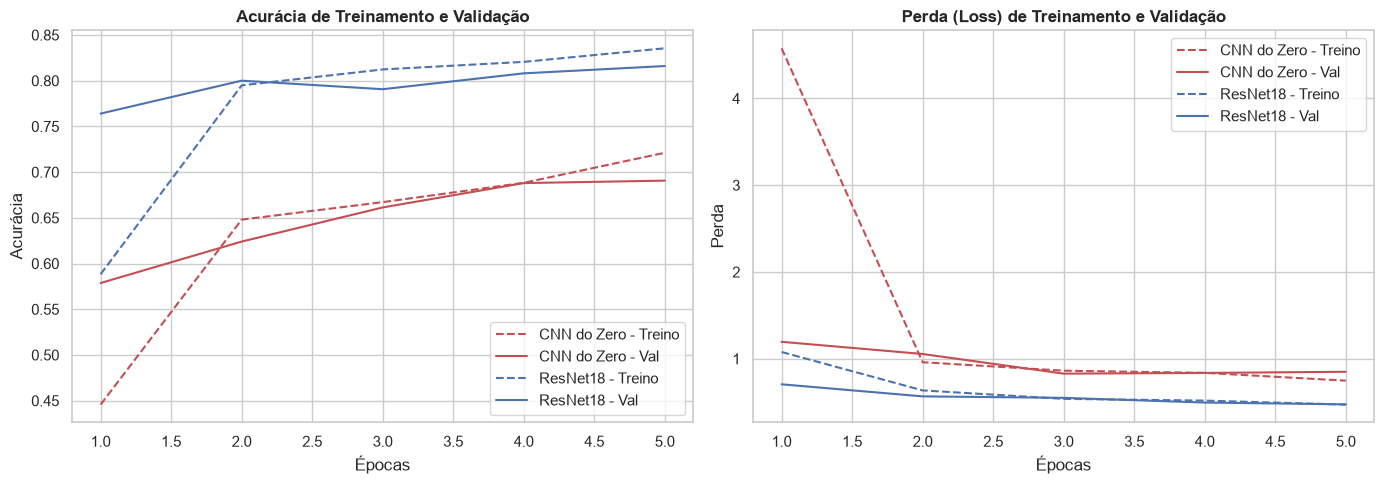

In [14]:
epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(14, 5))

# Gráfico de Acurácia
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_scratch['train_acc'], 'r--', label='CNN do Zero - Treino')
plt.plot(epochs_range, history_scratch['val_acc'], 'r-', label='CNN do Zero - Val')
plt.plot(epochs_range, history_resnet['train_acc'], 'b--', label='ResNet18 - Treino')
plt.plot(epochs_range, history_resnet['val_acc'], 'b-', label='ResNet18 - Val')
plt.title('Acurácia de Treinamento e Validação', fontsize=12, fontweight='bold')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()

# Gráfico de Perda (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_scratch['train_loss'], 'r--', label='CNN do Zero - Treino')
plt.plot(epochs_range, history_scratch['val_loss'], 'r-', label='CNN do Zero - Val')
plt.plot(epochs_range, history_resnet['train_loss'], 'b--', label='ResNet18 - Treino')
plt.plot(epochs_range, history_resnet['val_loss'], 'b-', label='ResNet18 - Val')
plt.title('Perda (Loss) de Treinamento e Validação', fontsize=12, fontweight='bold')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()

plt.tight_layout()
plt.savefig('graficos/historico_treinamento.png', dpi=300)
plt.show()

In [15]:
def evaluate_model(model, dataloader, device, best_weights_path):
    model.load_state_dict(torch.load(best_weights_path))
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    return np.array(all_labels), np.array(all_preds)

In [16]:
# Avaliar CNN do Zero
y_true, y_pred_scratch = evaluate_model(model_scratch, test_loader, device, 'resultados/best_simple_cnn.pth')
acc_scratch = accuracy_score(y_true, y_pred_scratch)
f1_macro_scratch = f1_score(y_true, y_pred_scratch, average='macro')
f1_weighted_scratch = f1_score(y_true, y_pred_scratch, average='weighted')

print("="*60)
print("RELATÓRIO DE AVALIAÇÃO DA CNN CUSTOMIZADA (DO ZERO)")
print(f"Acurácia Global: {acc_scratch:.4f}")
print(f"F1-Score (Macro): {f1_macro_scratch:.4f}")
print(f"F1-Score (Weighted): {f1_weighted_scratch:.4f}")
print("Relatório Completo:")
print(classification_report(y_true, y_pred_scratch, target_names=TARGET_CLASSES))

# Avaliar ResNet18
_, y_pred_resnet = evaluate_model(model_resnet, test_loader, device, 'resultados/best_resnet18.pth')
acc_resnet = accuracy_score(y_true, y_pred_resnet)
f1_macro_resnet = f1_score(y_true, y_pred_resnet, average='macro')
f1_weighted_resnet = f1_score(y_true, y_pred_resnet, average='weighted')

print("="*60)
print("RELATÓRIO DE AVALIAÇÃO DA RESNET18 (TRANSFER LEARNING)")
print(f"Acurácia Global: {acc_resnet:.4f}")
print(f"F1-Score (Macro): {f1_macro_resnet:.4f}")
print(f"F1-Score (Weighted): {f1_weighted_resnet:.4f}")
print("Relatório Completo:")
print(classification_report(y_true, y_pred_resnet, target_names=TARGET_CLASSES))

RELATÓRIO DE AVALIAÇÃO DA CNN CUSTOMIZADA (DO ZERO)
Acurácia Global: 0.7160
F1-Score (Macro): 0.7142
F1-Score (Weighted): 0.7142
Relatório Completo:
                       precision    recall  f1-score   support

  Xanthoria parietina       0.96      0.69      0.81       150
    Fomes fomentarius       0.64      0.89      0.75       150
  Fomitopsis pinicola       0.60      0.50      0.55       150
     Amanita muscaria       0.78      0.69      0.73       150
Laetiporus sulphureus       0.69      0.80      0.74       150

             accuracy                           0.72       750
            macro avg       0.73      0.72      0.71       750
         weighted avg       0.73      0.72      0.71       750



RELATÓRIO DE AVALIAÇÃO DA RESNET18 (TRANSFER LEARNING)
Acurácia Global: 0.8400
F1-Score (Macro): 0.8418
F1-Score (Weighted): 0.8418
Relatório Completo:
                       precision    recall  f1-score   support

  Xanthoria parietina       0.97      0.91      0.94       150
    Fomes fomentarius       0.83      0.75      0.79       150
  Fomitopsis pinicola       0.68      0.83      0.75       150
     Amanita muscaria       0.88      0.93      0.90       150
Laetiporus sulphureus       0.89      0.78      0.83       150

             accuracy                           0.84       750
            macro avg       0.85      0.84      0.84       750
         weighted avg       0.85      0.84      0.84       750



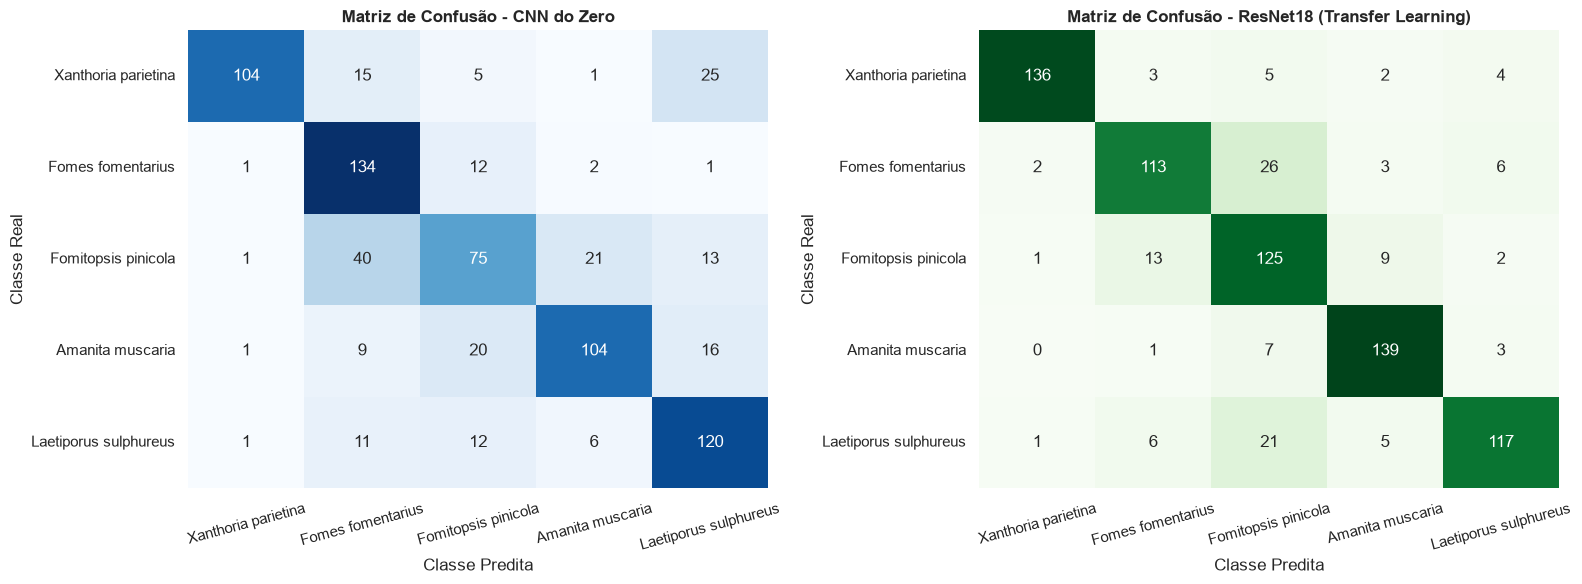

Métricas comparativas salvas em resultados/comparacao_modelos.csv


In [17]:
# Plotar e salvar a Matriz de Confusão para ambos os modelos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matriz CNN do Zero
cm_scratch = confusion_matrix(y_true, y_pred_scratch)
sns.heatmap(cm_scratch, annot=True, fmt='d', cmap='Blues', xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES, ax=axes[0], cbar=False)
axes[0].set_title('Matriz de Confusão - CNN do Zero', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Classe Predita')
axes[0].set_ylabel('Classe Real')

# Matriz ResNet18
cm_resnet = confusion_matrix(y_true, y_pred_resnet)
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Greens', xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES, ax=axes[1], cbar=False)
axes[1].set_title('Matriz de Confusão - ResNet18 (Transfer Learning)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Classe Predita')
axes[1].set_ylabel('Classe Real')

for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15)

plt.tight_layout()
plt.savefig('graficos/matriz_confusao.png', dpi=300)
plt.show()

# Exportar resultados para arquivo CSV
comparison_metrics = {
    'Modelo': ['CNN do Zero', 'ResNet18 (Transfer Learning)'],
    'Acuracia': [acc_scratch, acc_resnet],
    'F1_Macro': [f1_macro_scratch, f1_macro_resnet],
    'F1_Weighted': [f1_weighted_scratch, f1_weighted_resnet]
}
df_metrics = pd.DataFrame(comparison_metrics)
df_metrics.to_csv('resultados/comparacao_modelos.csv', index=False)
print("Métricas comparativas salvas em resultados/comparacao_modelos.csv")